# MNIST evaluation notebook (SNN vs MC Dropout vs EDL)

Thin notebook wrapper around `snn_eval.run_mnist`. Every training / inference / metrics / plotting step below calls `run_mnist.compute()` and `run_mnist.display()` directly — nothing here re-implements that logic, so any fix made in `run_mnist.py` is picked up automatically next time this notebook runs.

Section 2 shows the one extension point (`compute(args, loader=..., exp_name=...)`) that lets this same pipeline run against another MNIST-shaped dataset without touching training/inference/metrics code.

In [3]:
!git clone https://github.com/Ouatt-Isma/Subjective-Neural-Network-Framework.git
%cd Subjective-Neural-Network-Framework
!pip install -q -r requirements.txt

Cloning into 'Subjective-Neural-Network-Framework'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 72 (delta 35), reused 69 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 71.89 KiB | 10.27 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/Subjective-Neural-Network-Framework/Subjective-Neural-Network-Framework


In [4]:
%matplotlib inline
import argparse
import pandas as pd
from snn_eval import run_mnist, cache

In [5]:
def run_cached(exp_name, args, loader=None):
    """Thin caching wrapper around run_mnist.compute(), mirroring run_mnist.main().

    Avoids retraining / re-running inference on every notebook re-run: results
    are keyed by all params (like the CLI's results cache) and models by the
    train-only subset (like the CLI's model cache, handled inside compute()
    itself). Delete results/cache or results/models to force a clean re-run.
    """
    params = {k: v for k, v in vars(args).items() if k not in ("device", "no_cache")}
    res = None if args.no_cache else cache.load_results(exp_name, params)
    if res is None:
        res = run_mnist.compute(args, loader=loader, exp_name=exp_name)
        cache.save_results(exp_name, params, res)
    return res

## 1. MNIST (default loader)

`build_argparser()` is the exact same parser `run_mnist.py` uses from the CLI, so `parse_args([])` gives a `Namespace` of CLI defaults — tweak individual fields below instead of re-typing them.

In [13]:
args = run_mnist.build_argparser().parse_args([])  # identical defaults to the CLI
args.arch = "resnet"  # "mlp" | "cnn" | "resnet"
args.device  = "cuda"     # you're on Colab — use the GPU instead of "cpu"
args.epochs  = 15
args.Np      = 10
args.Nm      = 10
args.beta_max = 10

QUICK = False  # flip to False for the full paper-grade run
if QUICK:
    args.epochs, args.Np, args.Nm, args.T = 2, 3, 3, 20
    args.rot_step, args.rot_n = 45, 200

vars(args)

{'arch': 'resnet',
 'synthetic': False,
 'device': 'cuda',
 'epochs': 15,
 'd_hidden': 256,
 'beta_max': 10,
 'Np': 10,
 'Nm': 10,
 'T': 100,
 'rot_step': 15,
 'rot_n': 1000,
 'seed': 0,
 'no_cache': False}

In [14]:
res = run_cached("run_mnist", args)

arch=resnet  train=60000  test=10000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 937/937 [00:17<00:00, 53.45it/s]


  ep   1/15 loss=0.1727 tr_acc=0.9488 te_acc=0.9504 kl=23.1 beta=6.66 std(E[p])=0.0055


Epoch 2/15: 100%|██████████| 937/937 [00:14<00:00, 66.28it/s]


  ep   2/15 loss=0.0592 tr_acc=0.9831 te_acc=0.9749 kl=20.1 beta=10.00 std(E[p])=0.0039


...

  120°  acc=0.250  u*=0.063  u_e=0.0199  H=0.715


  135°  acc=0.368  u*=0.049  u_e=0.0147  H=0.656


  150°  acc=0.412  u*=0.030  u_e=0.0090  H=0.585


  165°  acc=0.429  u*=0.025  u_e=0.0068  H=0.561


  180°  acc=0.435  u*=0.026  u_e=0.0080  H=0.562
[results] saved → results/cache/run_mnist_470a1af689b2_results.json



arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.994  0.021  0.003     0.938
EDL                 0.959  0.205  0.076     0.964
SNN (mean, H)       0.994  0.021  0.004     0.975
SNN (u* counts)     0.994  0.021  0.004     0.484
SNN (aug P soft)    0.994  0.129  0.103     0.258

Rotation sweep (means over 1000 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | EDL u  EDL H 
    0 | 0.994  0.002   0.0006  0.004   0.473  | 0.018  0.0008  0.008   | 0.145  0.544 
   15 | 0.980  0.004   0.0012  0.005   0.480  | 0.045  0.0019  0.020   | 0.209  0.689 
   30 | 0.895  0.018   0.0053  0.026   0.536  | 0.183  0.0090  0.081   | 0.355  1.017 
   45 | 0.617  0.050   0.0149  0.066   0.660  | 0.329  0.0170  0.144   | 0.539  1.411 
   60 | 0.318  0.067   0.0191  0.085   0.724  | 0.388  0.0215  0.170   | 0.574  1.490 
   75 | 0.204  0.070   0.0201  0.095   0.744  | 0.411  0.0205  0.176   | 0.537  1.428 
   90 | 0.178  0.073   0.0196  0.088

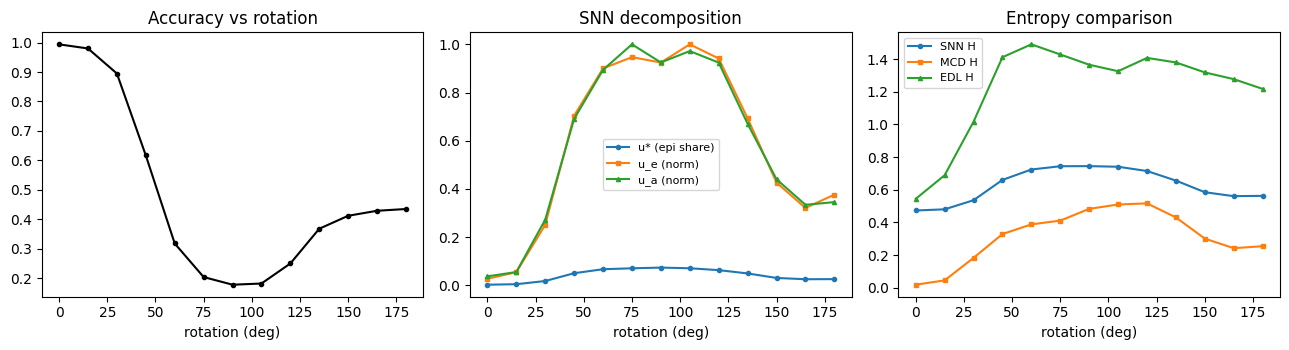

In [15]:
fig = run_mnist.display(res)  # prints tables + sweep, saves results/rotation_sweep.{csv,png}, shows inline

In [16]:
pd.DataFrame(res["table"])

,name,acc,nll,ece,ood_auroc
0,MC Dropout,0.9936,0.021048,0.002815,0.938031
1,EDL,0.9591,0.205186,0.075903,0.963612
2,"SNN (mean, H)",0.9937,0.021363,0.003551,0.975188
3,SNN (u* counts),0.9937,0.021363,0.003551,0.483998
4,SNN (aug P soft),0.9937,0.128815,0.102533,0.257933


## 2. Adapting to another dataset

`compute()` accepts a `loader` — any zero-arg callable returning `((Xtr, ytr), (Xte, yte), Xood)` with images shaped `(N, 1, 28, 28)` and integer labels, exactly like `run_mnist.load_mnist`. Pass a different one and the rest of the pipeline (model build, training, nested sampling, MC Dropout, EDL, metrics, rotation sweep, plotting) is untouched — `compute()` now infers `K` from the labels rather than hardcoding 10.

Use a distinct `exp_name` so the alternate run's model/result cache doesn't collide with the MNIST one, and a distinct `out_prefix` in `display()` so the CSV/PNG don't overwrite `rotation_sweep.*`.

**Scope caveat:** the CNN/ResNet backbones in `models.py` (`_CNNBackbone`, `_TinyResNet`) are hardcoded for single-channel 28×28 input, so this loader-swap trick is only valid for other MNIST-shaped datasets (FashionMNIST, KMNIST, EMNIST, ...). For a genuinely different shape/channel-count/class-count (e.g. CIFAR-10), use the repo's other evaluation-ladder rungs instead — `run_exp1.py` (frozen DINOv2/CLIP backbone) or `train_fullnet.py` (full ResNet18/WRN-28-10) — rather than forcing this MNIST pipeline.

In [10]:
def load_fashion_as_id(root="./data", ntr=60000, nte=10000):
    """Same return contract as run_mnist.load_mnist, but FashionMNIST is ID and
    MNIST is OOD (roles swapped). Swap the dataset names for KMNIST/EMNIST etc.
    """
    import torch
    import torchvision as tv, torchvision.transforms as T
    tf = T.ToTensor()
    tr  = tv.datasets.FashionMNIST(root, train=True,  download=True, transform=tf)
    te  = tv.datasets.FashionMNIST(root, train=False, download=True, transform=tf)
    ood = tv.datasets.MNIST(root, train=False, download=True, transform=tf)
    def imgs(ds, n):
        X = torch.stack([ds[i][0] for i in range(min(n, len(ds)))])
        y = torch.tensor([ds[i][1] for i in range(min(n, len(ds)))])
        return X, y
    return imgs(tr, ntr), imgs(te, nte), imgs(ood, nte)[0]

arch=mlp  train=60000  test=10000  hidden=256

[training SNN]


Epoch 1/2: 100%|██████████| 937/937 [00:05<00:00, 159.87it/s]


  ep   1/2 loss=0.4652 tr_acc=0.8313 te_acc=0.8571 kl=23.1 beta=10.00 std(E[p])=0.0058


Epoch 2/2: 100%|██████████| 937/937 [00:06<00:00, 146.43it/s]


  ep   2/2 loss=0.3466 tr_acc=0.8737 te_acc=0.8662 kl=21.9 beta=10.00 std(E[p])=0.0073
[training MC Dropout]


...

    0°  acc=0.880  u*=0.049  u_e=0.0290  H=1.144


   45°  acc=0.170  u*=0.186  u_e=0.1145  H=1.498


   90°  acc=0.010  u*=0.111  u_e=0.0686  H=1.298


  135°  acc=0.125  u*=0.186  u_e=0.1180  H=1.477


  180°  acc=0.195  u*=0.177  u_e=0.1032  H=1.437
[results] saved → results/cache/fashion_mnist_542d8728d1d1_results.json

arch=mlp

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.866  0.386  0.034     0.845
EDL                 0.860  0.677  0.160     0.740
SNN (mean, H)       0.874  0.350  0.010     0.882
SNN (u* counts)     0.874  0.350  0.010     0.659
SNN (aug P soft)    0.874  0.581  0.215     0.614

Rotation sweep (means over 200 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | EDL u  EDL H 
    0 | 0.880  0.049   0.0290  0.052   1.144  | 0.441  0.0217  0.204   | 0.325  1.130 
   45 | 0.170  0.186   0.1145  0.240   1.498  | 1.224  0.0843  0.523   | 0.653  1.918 
   90 | 0.010  0.111   0.0686  0.127   1.298  | 0.770  0.0504  0.305   | 0.407  1.301 
  135 | 0.125  0.186   0.1180  0.212   1.477  | 1.142  0.0739  0.467   | 0.555  1.682 
  180 | 0.195  0.177   0.1032  0.174   1.437  | 0.990  0.0570  0.429   | 0.643  1.833 
saved 

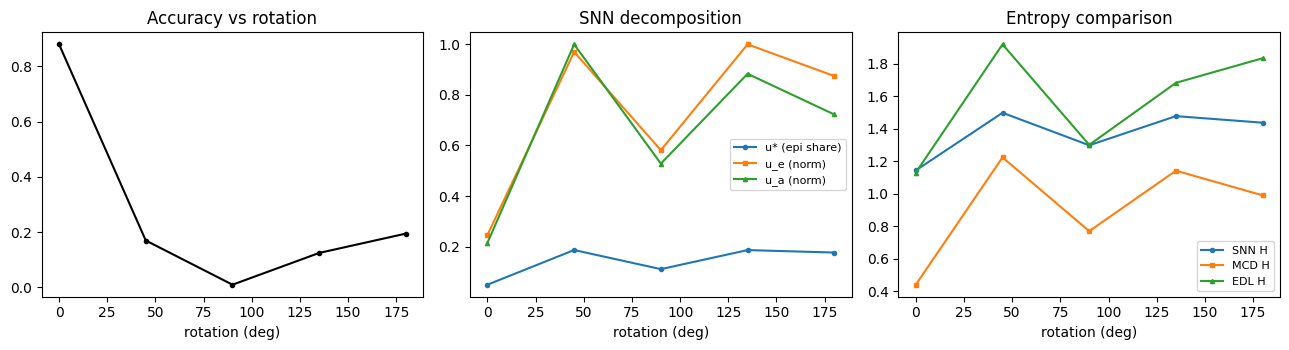

In [11]:
args_fashion = argparse.Namespace(**vars(args))  # same knobs, incl. QUICK tweaks

res_fashion = run_cached("fashion_mnist", args_fashion, loader=load_fashion_as_id)
fig_fashion = run_mnist.display(res_fashion, out_prefix="fashion_rotation_sweep")

## 3. Compare datasets side by side

Both `res` dicts came from the same `compute()`, so the table rows line up directly — no metric recomputation here, just reshaping already-computed numbers.

In [12]:
t1 = pd.DataFrame(res["table"]).assign(dataset="MNIST")
t2 = pd.DataFrame(res_fashion["table"]).assign(dataset="FashionMNIST(ID)/MNIST(OOD)")
pd.concat([t1, t2]).set_index(["dataset", "name"])

acc       nll       ece  \
dataset                     name                                           
MNIST                       MC Dropout        0.9715  0.107653  0.028253   
                            EDL               0.9549  0.341596  0.162841   
                            SNN (mean, H)     0.9736  0.093677  0.016070   
                            SNN (u* counts)   0.9736  0.093677  0.016070   
                            SNN (aug P soft)  0.9736  0.375871  0.258687   
FashionMNIST(ID)/MNIST(OOD) MC Dropout        0.8656  0.386032  0.033842   
                            EDL               0.8595  0.676723  0.160499   
                            SNN (mean, H)     0.8741  0.349669  0.009548   
                            SNN (u* counts)   0.8741  0.349669  0.009548   
                            SNN (aug P soft)  0.8741  0.581226  0.214884   

                                              ood_auroc  
dataset                     name                         
MNIST                       MC Dropout         0.864628  
                            EDL                0.876149  
                            SNN (mean, H)      0.898871  
                            SNN (u* counts)    0.588557  
                            SNN (aug P soft)   0.443484  
FashionMNIST(ID)/MNIST(OOD) MC Dropout         0.844549  
                            EDL                0.739995  
                            SNN (mean, H)      0.882363  
                            SNN (u* counts)    0.659455  
                            SNN (aug P soft)   0.613543

## 4. Epistemic probe — data scarcity (n_train sweep)

Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST (100 → 60 k samples).
With less data the trust parameters have fewer gradient steps to converge → they stay in the diffuse `epistemic_flat` / `epistemic_u` regime → different outer trust draws make **different** predictions → MI (u_e) rises.

Expected:  **`snn_u_e` (MI) ↑** as `n_train` ↓; `u_a` (eH) stays relatively low (not a noise problem).
The `n_train = 60000` row should match Section 1.

In [ ]:
# Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST.
# With less data, trust parameters have fewer gradient steps to converge →
# they stay in the diffuse epistemic_flat / epistemic_u regime → different outer
# trust draws make DIFFERENT predictions → MI (u_e) rises.

n_train_levels = [100, 500, 1000, 5000, 60000]
epi_rows = []
for n in n_train_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = n, 0.0, False
    r = run_cached(f"epi_n{n}", a)
    s0  = r["sweep"][0]   # angle=0°  (in-distribution, no rotation)
    tbl = {row["name"]: row for row in r["table"]}
    epi_rows.append({
        "n_train":      n,
        "acc":          round(s0[1],  4),
        "snn_u_e (MI)": round(s0[3],  5),
        "snn_u_a (eH)": round(s0[4],  5),
        "snn_u*":       round(s0[2],  4),
        "mcd_u_e":      round(s0[10], 5),
        "ood_auroc_H":  round(tbl["SNN (mean, H)"]["ood_auroc"], 4),
    })

df_epi = pd.DataFrame(epi_rows)
display(df_epi)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    axes[0].semilogx(df_epi["n_train"], df_epi["acc"], "k-o", ms=5)
    axes[0].set_xlabel("n_train"); axes[0].set_title("Accuracy")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_e (MI)"], "-o", ms=5, label="SNN u_e (MI)")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_a (eH)"], "-s", ms=5, label="SNN u_a (eH)")
    axes[1].semilogx(df_epi["n_train"], df_epi["mcd_u_e"],      "-^", ms=5, label="MCD u_e")
    axes[1].set_xlabel("n_train"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    axes[2].semilogx(df_epi["n_train"], df_epi["snn_u*"],      "-o", ms=5, label="SNN u* (epi share)")
    axes[2].semilogx(df_epi["n_train"], df_epi["ood_auroc_H"], "-s", ms=5, label="OOD-AUROC (H)")
    axes[2].set_xlabel("n_train"); axes[2].set_title("Epistemic share & OOD")
    axes[2].legend(fontsize=8)
    fig.suptitle("Epistemic probe: data scarcity  (n_train sweep)", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_epistemic_n_train.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 5. Aleatoric probe — label noise

Train on all 60 k MNIST images but randomly flip `label_noise` fraction of training labels.
The test set is always **clean** — any uncertainty on test images reflects the noisy decision boundary baked in during training.

Expected: **`u_a` (eH) ↑** as noise rises; `u_e` (MI) lower than the data-scarcity case because trust draws agree on *what* is uncertain even when they can't agree on a class (aleatoric regime: α ≈ β >> 1).

In [ ]:
# Train on all 60 k MNIST images but randomly flip `label_noise` fraction of labels.
# Test set is always CLEAN — any uncertainty on test images reflects the noisy boundary
# baked in during training (pure aleatoric: same input can appear with different labels).
#
# Expected decomposition on clean test images:
#   u_a (eH) ↑  — model learns an irreducibly uncertain boundary; each trust draw is less sharp
#   u_e (MI) lower than in the data-scarcity case — trust draws AGREE on their uncertainty
#   (contrast Sec 4 where draws DISAGREE on the correct prediction → high MI)

noise_levels = [0.0, 0.1, 0.2, 0.4]
alea_rows = []
for rate in noise_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = 60000, rate, False
    r = run_cached(f"alea_noise{int(rate * 100):02d}", a)
    s0 = r["sweep"][0]   # angle=0°  (clean in-distribution)
    alea_rows.append({
        "label_noise":   rate,
        "acc":           round(s0[1],  4),
        "snn_u_e (MI)":  round(s0[3],  5),
        "snn_u_a (eH)":  round(s0[4],  5),
        "snn_u*":        round(s0[2],  4),
        "mcd_u_e":       round(s0[10], 5),
        "mcd_u_a":       round(s0[11], 5),
    })

df_alea = pd.DataFrame(alea_rows)
display(df_alea)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_alea["label_noise"], df_alea["acc"], "k-o", ms=5)
    axes[0].set_xlabel("label_noise rate"); axes[0].set_title("Accuracy (on clean test set)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_e (MI)"],  "-o", ms=5, label="SNN u_e (MI)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_a (eH)"],  "-s", ms=5, label="SNN u_a (eH)")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_e"],       "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_a"],       "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("label_noise rate"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: label noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_label_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 6. Aleatoric probe — pixel noise at inference

No retraining: add Gaussian noise N(0, σ²) to clean test images and re-run inference on the baseline model.

Each trust draw sees the **same noisy image** and is individually uncertain → eH rises.
Cross-draw disagreement (MI) stays low because all trust draws face the same ambiguous input.

Expected:  **`snn_u_a` (eH) ↑** as σ grows; **`snn_u_e` (MI) stays flat**; `u* = MI/H` stays low.

In [ ]:
import torchvision as tv, torchvision.transforms as T
import torch, os

# Load baseline trained models from cache (no retraining if Section 1 already ran).
base_args = run_mnist.build_argparser().parse_args([])
base_args.arch, base_args.device, base_args.epochs = args.arch, args.device, args.epochs
base_args.n_train, base_args.label_noise = 60000, 0.0

tf = T.ToTensor()
te_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=tf)
n_probe = 2000
Xte_i = torch.stack([te_ds[i][0] for i in range(n_probe)])
yte   = torch.tensor([te_ds[i][1] for i in range(n_probe)])

tr_ds  = tv.datasets.MNIST("./data", train=True, download=True, transform=tf)
Xtr_i2 = torch.stack([tr_ds[i][0] for i in range(min(2000, len(tr_ds)))])
ytr2   = torch.tensor([tr_ds[i][1] for i in range(len(Xtr_i2))])

heads = run_mnist.build_or_train_models(
    base_args, K=10,
    Xtr=run_mnist._prep_inputs(Xtr_i2, base_args.arch), ytr=ytr2,
    Xte=run_mnist._prep_inputs(Xte_i,  base_args.arch), yte=yte,
    exp_name="run_mnist"
)

os.makedirs("results", exist_ok=True)
noise_rows = run_mnist.pixel_noise_probe(
    heads, Xte_i, yte, base_args, K=10,
    sigmas=[0.0, 0.05, 0.1, 0.2, 0.4, 0.8]
)
df_noise = pd.DataFrame(noise_rows)
display(df_noise[["sigma", "acc", "snn_u_e", "snn_u_a", "snn_u", "mcd_u_e", "mcd_u_a", "edl_u"]])

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_noise["sigma"], df_noise["acc"], "k-o", ms=5)
    axes[0].set_xlabel("pixel noise σ"); axes[0].set_title("Accuracy")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_e"], "-o", ms=5, label="SNN u_e (MI, epistemic)")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_a"], "-s", ms=5, label="SNN u_a (eH, aleatoric)")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_e"], "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_a"], "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("pixel noise σ"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: inference-time pixel noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_pixel_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 7. Epistemic probe — unseen classes (class-split OOD)

Train on digits 0–4 only; OOD = digits 5–9 the model has never seen.
This is a controlled epistemic gap: the model has the capacity but lacks training signal for those output directions, so trust parameters for unseen-class feature regions should stay diffuse → high MI (u_e).

Expected:  OOD-AUROC high for `u_e` / `u*` / `H`; `u_e >> u_a` on the unseen-class split.

In [ ]:

# Train only on digits 0–4; OOD = digits 5–9 (model has no training signal there).
# Expected: high u_e (MI) on unseen-class images — trust parameters remain diffuse
# for feature regions the model has never trained on (pure epistemic gap).

def load_split():
    return run_mnist.load_mnist_class_split(id_classes=(0, 1, 2, 3, 4), nte=1000)

a_split = run_mnist.build_argparser().parse_args([])
a_split.arch, a_split.device, a_split.epochs = args.arch, args.device, args.epochs
a_split.n_train, a_split.label_noise, a_split.no_cache = 60000, 0.0, False
a_split.rot_step, a_split.rot_n = 90, 200   # shorter rotation sweep

r_split = run_cached("class_split_0to4", a_split, loader=load_split)
print("\nClass-split OOD probe  (train=digits 0–4, OOD=digits 5–9):")
fig_split = run_mnist.display(r_split, out_prefix="class_split_rotation")
